# Exploratory Data Analysis (EDA) on Hotel Booking Demand Dataset

Author: Ashwin S

Internship: Thiranex Data Science Internship

Assignment 3

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,7/3/2015


In [5]:
print("Shape of Dataset:", df.shape)

df.info()

df.describe(include='all')

Shape of Dataset: (66478, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66478 entries, 0 to 66477
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           66478 non-null  object 
 1   is_canceled                     66478 non-null  int64  
 2   lead_time                       66478 non-null  int64  
 3   arrival_date_year               66478 non-null  int64  
 4   arrival_date_month              66478 non-null  object 
 5   arrival_date_week_number        66478 non-null  int64  
 6   arrival_date_day_of_month       66478 non-null  int64  
 7   stays_in_weekend_nights         66478 non-null  int64  
 8   stays_in_week_nights            66478 non-null  int64  
 9   adults                          66477 non-null  float64
 10  children                        66473 non-null  float64
 11  babies                          66477 non-null  float64
 12  me

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,66478,66478.000000,66478.000000,66478.000000,66478,66478.000000,66478.000000,66478.000000,66478.000000,66477.000000,...,66477,56353.000000,3745.000000,66477.000000,66477,66477.000000,66477.000000,66477.000000,66477,66477
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,921
top,Resort Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,10/21/2015
freq,40060,NaN,NaN,NaN,7714,NaN,NaN,NaN,NaN,NaN,...,57311,NaN,NaN,NaN,49965,NaN,NaN,NaN,34681,1409
mean,NaN,0.478309,104.319173,2016.043894,NaN,27.519495,15.672764,1.030973,2.801408,1.864840,...,NaN,133.701347,223.186649,3.325331,NaN,96.328269,0.085654,0.498624,NaN,NaN
std,NaN,0.499533,107.468148,0.695323,NaN,14.174810,8.803593,1.083216,2.187938,0.619019,...,NaN,121.083044,130.339707,22.218717,NaN,56.120022,0.284333,0.762989,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,19.000000,2016.000000,NaN,15.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,110.000000,0.000000,NaN,62.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,70.000000,2016.000000,NaN,29.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,134.000000,223.000000,0.000000,NaN,85.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,39.000000,23.000000,2.000000,4.000000,2.000000,...,NaN,240.000000,307.000000,0.000000,NaN,120.000000,0.000000,1.000000,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
company,62733
agent,10125
country,487
children,5
meal,1
babies,1
adults,1
distribution_channel,1
previous_cancellations,1
booking_changes,1


In [7]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

18007


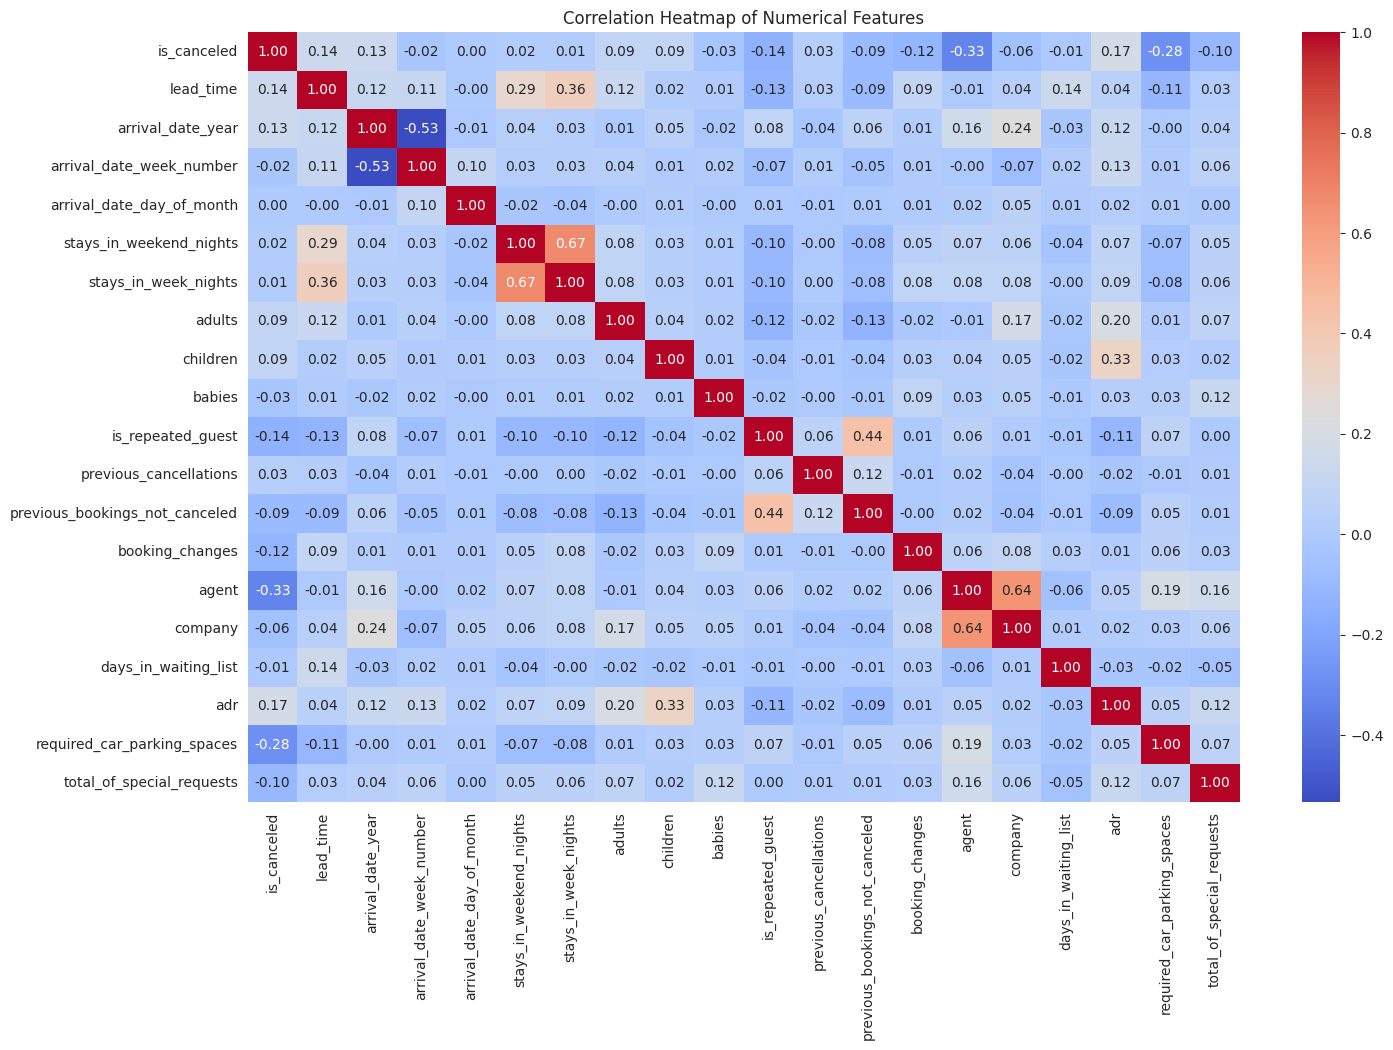

In [9]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()